<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/1b_DBA_archived_hpi_grth_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

Adding for data from the new process

In [75]:
df = pd.read_csv('/content/final_model_dataset.csv')
print("Top 5 records:")
print(df.head())
print("\nShape of the DataFrame:")
print(df.shape)

Top 5 records:
        city  quarter      rent        hpi  rent_growth  hpi_growth  \
0  bangalore  Q1 2015  104.4500  61.806841     0.043538    0.237475   
1  bangalore  Q1 2016  114.6000  71.406332     0.092739    0.144372   
2  bangalore  Q1 2017  121.9875  75.582470     0.062471    0.056838   
3  bangalore  Q1 2018  145.2250  77.997789     0.174366    0.031456   
4  bangalore  Q1 2019  144.7375  83.885498    -0.003363    0.072772   

   valuation_gap  repo_rate   hpi_lag  rent_lag  
0      -0.193937   7.782887       NaN       NaN  
1      -0.051633   7.657853  0.237475  0.043538  
2       0.005633   6.962920  0.144372  0.092739  
3       0.142910   7.466353  0.056838  0.062471  
4      -0.076135   7.397403  0.031456  0.174366  

Shape of the DataFrame:
(175, 10)


In [76]:
df = pd.read_csv("final_model_dataset.csv")

df = df.sort_values(["city","quarter"])
df["rent_growth"] = df.groupby("city")["rent"].pct_change(fill_method=None)
# Assuming 'repo_rate' column exists in the CSV for repo rate calculation
df["repo_growth"] = df.groupby("city")["repo_rate"].pct_change(fill_method=None)
df = df.dropna(subset=["rent_growth","hpi_growth","repo_growth"])
#Ensure Categorical FE
df["city"]=df["city"].astype("category")

In [77]:
#ADF

In [78]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f}")

for city in df["city"].unique():
    print(f"\nADF - {city}")
    adf_test(df[df["city"]==city]["rent_growth"], "rent_growth")
    adf_test(df[df["city"]==city]["hpi_growth"], "hpi_growth")


ADF - bangalore
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0000

ADF - chennai
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0000

ADF - delhi
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.3887

ADF - mumbai
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0001


In [79]:
X = df[["rent_growth"]].copy()
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

       feature       VIF
0        const  1.113895
1  rent_growth  1.000000


In [80]:
X = df[["rent_growth","hpi_growth"]].dropna()
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

       feature       VIF
0        const  1.510399
1  rent_growth  1.000381
2   hpi_growth  1.000381


In [81]:
model = smf.ols(
    "hpi_growth ~ rent_growth + C(city)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     3.038
Date:                Thu, 30 Apr 2026   Prob (F-statistic):             0.0192
Time:                        11:02:47   Log-Likelihood:                 173.97
No. Observations:                 155   AIC:                            -337.9
Df Residuals:                     150   BIC:                            -322.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0638      0

In [82]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

print("BP p-value:", bp_test[1])

BP p-value: 0.07931312654328068


In [83]:
model_hac = smf.ols(
      "hpi_growth ~ rent_growth + C(city)",
          data=df
          ).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_hac.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     2.519
Date:                Thu, 30 Apr 2026   Prob (F-statistic):             0.0436
Time:                        11:02:47   Log-Likelihood:                 173.97
No. Observations:                 155   AIC:                            -337.9
Df Residuals:                     150   BIC:                            -322.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0638      0

In [84]:
df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)

df_dyn = df.dropna()

model_dyn = smf.ols(
    "hpi_growth ~ rent_growth + hpi_lag + C(city)",
        data=df_dyn
        ).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_dyn.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     2.222
Date:                Thu, 30 Apr 2026   Prob (F-statistic):             0.0552
Time:                        11:02:47   Log-Likelihood:                 171.36
No. Observations:                 151   AIC:                            -330.7
Df Residuals:                     145   BIC:                            -312.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0572      0

/tmp/ipykernel_3223/1311684452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)


In [85]:
df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)

df_dyn = df.dropna()


/tmp/ipykernel_3223/3382915828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
/tmp/ipykernel_3223/3382915828.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)


In [86]:
# Add repo_growth to the dynamic model
model_dyn_with_repo = smf.ols(
    "hpi_growth ~ rent_growth + hpi_lag + repo_growth + C(city)",
    data=df_dyn
).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_dyn_with_repo.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     3.998
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           0.000986
Time:                        11:02:48   Log-Likelihood:                 178.51
No. Observations:                 151   AIC:                            -343.0
Df Residuals:                     144   BIC:                            -321.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0596      0

In [87]:
print(df.columns)

Index(['city', 'quarter', 'rent', 'hpi', 'rent_growth', 'hpi_growth',
       'valuation_gap', 'repo_rate', 'hpi_lag', 'rent_lag', 'repo_growth',
       'rent_growth_lag', 'repo_growth_lag'],
      dtype='object')


In [88]:
df  # your dataset

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,rent_growth_lag,repo_growth_lag
1,bangalore,Q1 2016,114.600000,71.406332,0.097176,0.144372,-0.051633,7.657853,NaN,0.043538,-0.016065,NaN,NaN
2,bangalore,Q1 2017,121.987500,75.582470,0.064463,0.056838,0.005633,6.962920,0.144372,0.092739,-0.090748,0.097176,-0.016065
3,bangalore,Q1 2018,145.225000,77.997789,0.190491,0.031456,0.142910,7.466353,0.056838,0.062471,0.072302,0.064463,-0.090748
4,bangalore,Q1 2019,144.737500,83.885498,-0.003357,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009235,0.190491,0.072302
5,bangalore,Q1 2020,154.950000,91.129073,0.070559,0.082824,-0.014643,6.727675,0.072772,-0.003363,-0.090536,-0.003357,-0.009235
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,mumbai,Q4 2020,110.657143,90.592899,-0.010096,0.011342,-0.021489,5.910980,0.016050,0.063304,-0.114476,0.065351,-0.132456
171,mumbai,Q4 2021,108.457143,91.307325,-0.019881,0.007855,-0.027937,6.384825,0.011342,-0.010147,0.080164,-0.010096,-0.114476
172,mumbai,Q4 2022,114.485714,96.374888,0.055585,0.054015,0.000080,7.372220,0.007855,-0.020082,0.154647,-0.019881,0.080164
173,mumbai,Q4 2023,124.600000,100.695009,0.088345,0.043851,0.040808,7.281333,0.054015,0.054095,-0.012328,0.055585,0.154647


In [89]:
import statsmodels.formula.api as smf

In [90]:
formula = "hpi_growth ~ rent_growth + hpi_lag + repo_growth + C(city)"

In [91]:
formula = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth + C(city)"


In [92]:
model_50 = smf.quantreg(formula, df)
res_50 = model_50.fit(q=0.5)

print(res_50.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1520
Model:                       QuantReg   Bandwidth:                     0.05410
Method:                 Least Squares   Sparsity:                       0.1502
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0756      0.014      5.228      0.000       0.047       0.104
C(city)[T.chennai]     0.0202      0.018      1.155      0.250      -0.014       0.055
C(city)[T.delhi]      -0.0736      0.018     -4.056      0.000      -0.110      -0.038
C(city)[T.mu

In [93]:
model_50 = smf.quantreg(formula, df_dyn)
res_50 = model_50.fit(q=0.5)

print(res_50.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1520
Model:                       QuantReg   Bandwidth:                     0.05410
Method:                 Least Squares   Sparsity:                       0.1502
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0756      0.014      5.228      0.000       0.047       0.104
C(city)[T.chennai]     0.0202      0.018      1.155      0.250      -0.014       0.055
C(city)[T.delhi]      -0.0736      0.018     -4.056      0.000      -0.110      -0.038
C(city)[T.mu

In [94]:
model_10 = smf.quantreg(formula, df)
res_10 = model_10.fit(q=0.1)

print(res_10.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1707
Model:                       QuantReg   Bandwidth:                     0.06829
Method:                 Least Squares   Sparsity:                       0.3130
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0909      0.017     -5.375      0.000      -0.124      -0.057
C(city)[T.chennai]     0.1171      0.025      4.676      0.000       0.068       0.167
C(city)[T.delhi]      -0.0074      0.022     -0.333      0.740      -0.052       0.037
C(city)[T.mu

In [95]:
model_10 = smf.quantreg(formula, df_dyn)
res_10 = model_10.fit(q=0.1)

print(res_10.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1707
Model:                       QuantReg   Bandwidth:                     0.06829
Method:                 Least Squares   Sparsity:                       0.3130
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0909      0.017     -5.375      0.000      -0.124      -0.057
C(city)[T.chennai]     0.1171      0.025      4.676      0.000       0.068       0.167
C(city)[T.delhi]      -0.0074      0.022     -0.333      0.740      -0.052       0.037
C(city)[T.mu

In [96]:
model_90 = smf.quantreg(formula, df)
res_90 = model_90.fit(q=0.9)

print(res_90.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1804
Model:                       QuantReg   Bandwidth:                     0.06829
Method:                 Least Squares   Sparsity:                       0.2525
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1484      0.021      7.074      0.000       0.107       0.190
C(city)[T.chennai]     0.0727      0.021      3.464      0.001       0.031       0.114
C(city)[T.delhi]      -0.0192      0.023     -0.829      0.408      -0.065       0.027
C(city)[T.mu

In [97]:
model_90 = smf.quantreg(formula, df_dyn)
res_90 = model_90.fit(q=0.9)

print(res_90.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1804
Model:                       QuantReg   Bandwidth:                     0.06829
Method:                 Least Squares   Sparsity:                       0.2525
Date:                Thu, 30 Apr 2026   No. Observations:                  151
Time:                        11:02:48   Df Residuals:                      142
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1484      0.021      7.074      0.000       0.107       0.190
C(city)[T.chennai]     0.0727      0.021      3.464      0.001       0.031       0.114
C(city)[T.delhi]      -0.0192      0.023     -0.829      0.408      -0.065       0.027
C(city)[T.mu

In [98]:
import pandas as pd

coeffs = pd.DataFrame({
    "q10": res_10.params,
    "q50": res_50.params,
    "q90": res_90.params
})

print(coeffs)

                         q10       q50       q90
Intercept          -0.090924  0.075581  0.148407
C(city)[T.chennai]  0.117094  0.020235  0.072668
C(city)[T.delhi]   -0.007427 -0.073642 -0.019213
C(city)[T.mumbai]   0.045045 -0.028586 -0.021522
hpi_lag            -0.298488  0.106266 -0.212662
rent_growth_lag     0.080816 -0.051474 -0.253927
repo_growth_lag    -0.018042  0.024170 -0.305866
rent_growth         0.218106 -0.160156 -0.076511
repo_growth        -0.493926 -0.174877 -0.138972


In [99]:
coeffs = pd.DataFrame({
    "q10": res_10.params,
    "q50": res_50.params,
    "q90": res_90.params
})

print(coeffs)


                         q10       q50       q90
Intercept          -0.090924  0.075581  0.148407
C(city)[T.chennai]  0.117094  0.020235  0.072668
C(city)[T.delhi]   -0.007427 -0.073642 -0.019213
C(city)[T.mumbai]   0.045045 -0.028586 -0.021522
hpi_lag            -0.298488  0.106266 -0.212662
rent_growth_lag     0.080816 -0.051474 -0.253927
repo_growth_lag    -0.018042  0.024170 -0.305866
rent_growth         0.218106 -0.160156 -0.076511
repo_growth        -0.493926 -0.174877 -0.138972


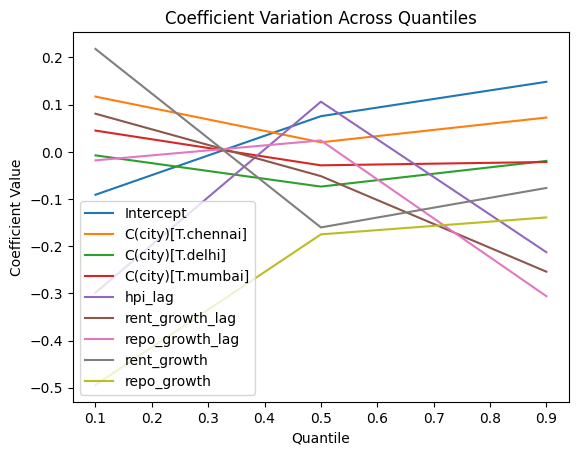

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

quantiles = [0.1, 0.5, 0.9]
results = []

for q in quantiles:
    res = smf.quantreg(formula, df).fit(q=q)
    results.append(res.params)

coef_df = pd.DataFrame(results, index=quantiles)

coef_df.plot()
plt.title("Coefficient Variation Across Quantiles")
plt.xlabel("Quantile")
plt.ylabel("Coefficient Value")
plt.show()

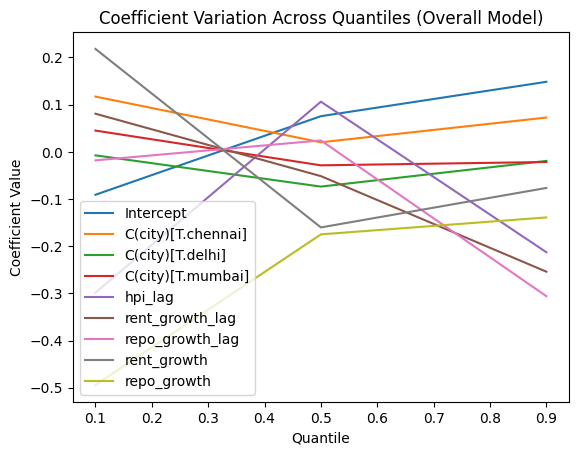

In [101]:
quantiles = [0.1, 0.5, 0.9]
results = []

for q in quantiles:
    res = smf.quantreg(formula, df_dyn).fit(q=q)
    results.append(res.params)

coef_df = pd.DataFrame(results, index=quantiles)

coef_df.plot()
plt.title("Coefficient Variation Across Quantiles (Overall Model)")
plt.xlabel("Quantile")
plt.ylabel("Coefficient Value")
plt.show()


In [102]:
df['quarter_formatted'] = df['quarter'].str.replace(r'Q(\d)\s(\d{4})', r'\2Q\1', regex=True)
df['quarter_dt'] = pd.PeriodIndex(df['quarter_formatted'], freq='Q').to_timestamp()
min_date = df['quarter_dt'].min()
max_date = df['quarter_dt'].max()
print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2014-04-01 00:00:00
Maximum Date: 2025-01-01 00:00:00


In [103]:
# Recreate df_dyn to ensure it includes the 'quarter_dt' column
df_dyn = df.dropna()
print(df_dyn['quarter_dt'].dt.year.unique())

[2017 2018 2019 2020 2021 2022 2023 2024 2025 2015 2016 2014]


In [104]:
display(df_dyn.describe())

,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,rent_growth_lag,repo_growth_lag,quarter_dt
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151
mean,131.355511,94.589240,0.029556,0.050225,-0.015919,6.984925,0.051048,0.017653,-0.004531,0.027141,-0.003175,2020-05-16 06:30:59.602649088
min,94.500000,59.203005,-0.431357,-0.293602,-0.341975,5.910980,-0.293602,-0.567730,-0.152852,-0.431357,-0.152852,2014-04-01 00:00:00
25%,111.214286,84.246868,-0.005867,-0.001333,-0.072469,6.675118,-0.000518,-0.012745,-0.084422,-0.007138,-0.084422,2018-01-01 00:00:00
50%,124.900000,96.239144,0.038140,0.054015,-0.023872,7.075500,0.056583,0.033678,-0.032784,0.037742,-0.022211,2020-07-01 00:00:00
75%,144.500000,104.117769,0.074884,0.100952,0.042875,7.361508,0.105089,0.068408,0.077027,0.071660,0.077027,2022-10-01 00:00:00
max,191.212500,136.959835,0.205856,0.275671,0.230875,8.791340,0.258031,0.187190,0.300879,0.205856,0.300879,2025-01-01 00:00:00
std,23.599149,15.026851,0.082668,0.081825,0.092415,0.536810,0.080881,0.099255,0.101856,0.085050,0.101348,NaN


### Quantile Regression Segmented by City

Now, let's run the quantile regression for each city individually to observe how the relationships between HPI growth, rent growth, lagged HPI growth, and repo rate growth differ across cities at various quantiles.

In [105]:
formula_city = "hpi_growth ~ rent_growth + hpi_lag + repo_growth"

unique_cities = df_dyn['city'].unique()

for city_name in unique_cities:
    print(f"\n--- City: {city_name.upper()} ---")
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7: # Need at least k+1 observations for k regressors (3 regressors + intercept = 4, so 7 to be safe for quantreg)
        print(f"Not enough observations for {city_name}. Skipping.")
        continue

    # Run Quantile Regression for q=0.1
    print("\n--- Quantile: 0.1 ---")
    model_10_city = smf.quantreg(formula_city, df_city)
    res_10_city = model_10_city.fit(q=0.1)
    print(res_10_city.summary())

    # Run Quantile Regression for q=0.5
    print("\n--- Quantile: 0.5 ---")
    model_50_city = smf.quantreg(formula_city, df_city)
    res_50_city = model_50_city.fit(q=0.5)
    print(res_50_city.summary())

    # Run Quantile Regression for q=0.9
    print("\n--- Quantile: 0.9 ---")
    model_90_city = smf.quantreg(formula_city, df_city)
    res_90_city = model_90_city.fit(q=0.9)
    print(res_90_city.summary())



--- City: BANGALORE ---

--- Quantile: 0.1 ---
                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.1828
Model:                       QuantReg   Bandwidth:                         nan
Method:                 Least Squares   Sparsity:                          nan
Date:                Thu, 30 Apr 2026   No. Observations:                   37
Time:                        11:02:49   Df Residuals:                       33
                                        Df Model:                            3
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.0178        nan        nan        nan         nan         nan
rent_growth    -0.5176        nan        nan        nan         nan         nan
hpi_lag        -0.3800        nan        nan        nan         nan         nan

In [106]:
formula_city = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth"

unique_cities = df_dyn['city'].unique()

for city_name in unique_cities:
    print(f"\n--- City: {city_name.upper()} ---")
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7: # Need at least k+1 observations for k regressors (5 regressors + intercept = 6)
        print(f"Not enough observations for {city_name}. Skipping.")
        continue

    # Run Quantile Regression for q=0.1
    print("\n--- Quantile: 0.1 ---")
    model_10_city = smf.quantreg(formula_city, df_city)
    res_10_city = model_10_city.fit(q=0.1)
    print(res_10_city.summary())

    # Run Quantile Regression for q=0.5
    print("\n--- Quantile: 0.5 ---")
    model_50_city = smf.quantreg(formula_city, df_city)
    res_50_city = model_50_city.fit(q=0.5)
    print(res_50_city.summary())

    # Run Quantile Regression for q=0.9
    print("\n--- Quantile: 0.9 ---")
    model_90_city = smf.quantreg(formula_city, df_city)
    res_90_city = model_90_city.fit(q=0.9)
    print(res_90_city.summary())



--- City: BANGALORE ---

--- Quantile: 0.1 ---
                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.3596
Model:                       QuantReg   Bandwidth:                         nan
Method:                 Least Squares   Sparsity:                          nan
Date:                Thu, 30 Apr 2026   No. Observations:                   37
Time:                        11:02:49   Df Residuals:                       31
                                        Df Model:                            5
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0065        nan        nan        nan         nan         nan
hpi_lag            -0.2925        nan        nan        nan         nan         nan
rent_growth_lag    -0.0518        nan        nan        nan    

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


### Quantile Regression Coefficients and Significance by City and Quantile



,City,Quantile,Variable,Coefficient,P-value,Significant (p<0.05)
0,bangalore,0.1,Intercept,-0.017825,NaN,False
1,bangalore,0.1,rent_growth,-0.517586,NaN,False
2,bangalore,0.1,hpi_lag,-0.379986,NaN,False
3,bangalore,0.1,repo_growth,-0.079240,NaN,False
4,bangalore,0.5,Intercept,0.081990,0.000013,True
5,bangalore,0.5,rent_growth,-0.210901,0.119169,False
6,bangalore,0.5,hpi_lag,0.064768,0.663793,False
7,bangalore,0.5,repo_growth,-0.195145,0.104007,False
8,bangalore,0.9,Intercept,0.143879,NaN,False
9,bangalore,0.9,rent_growth,-0.006035,NaN,False



### Visualization of Coefficients Across Quantiles by City



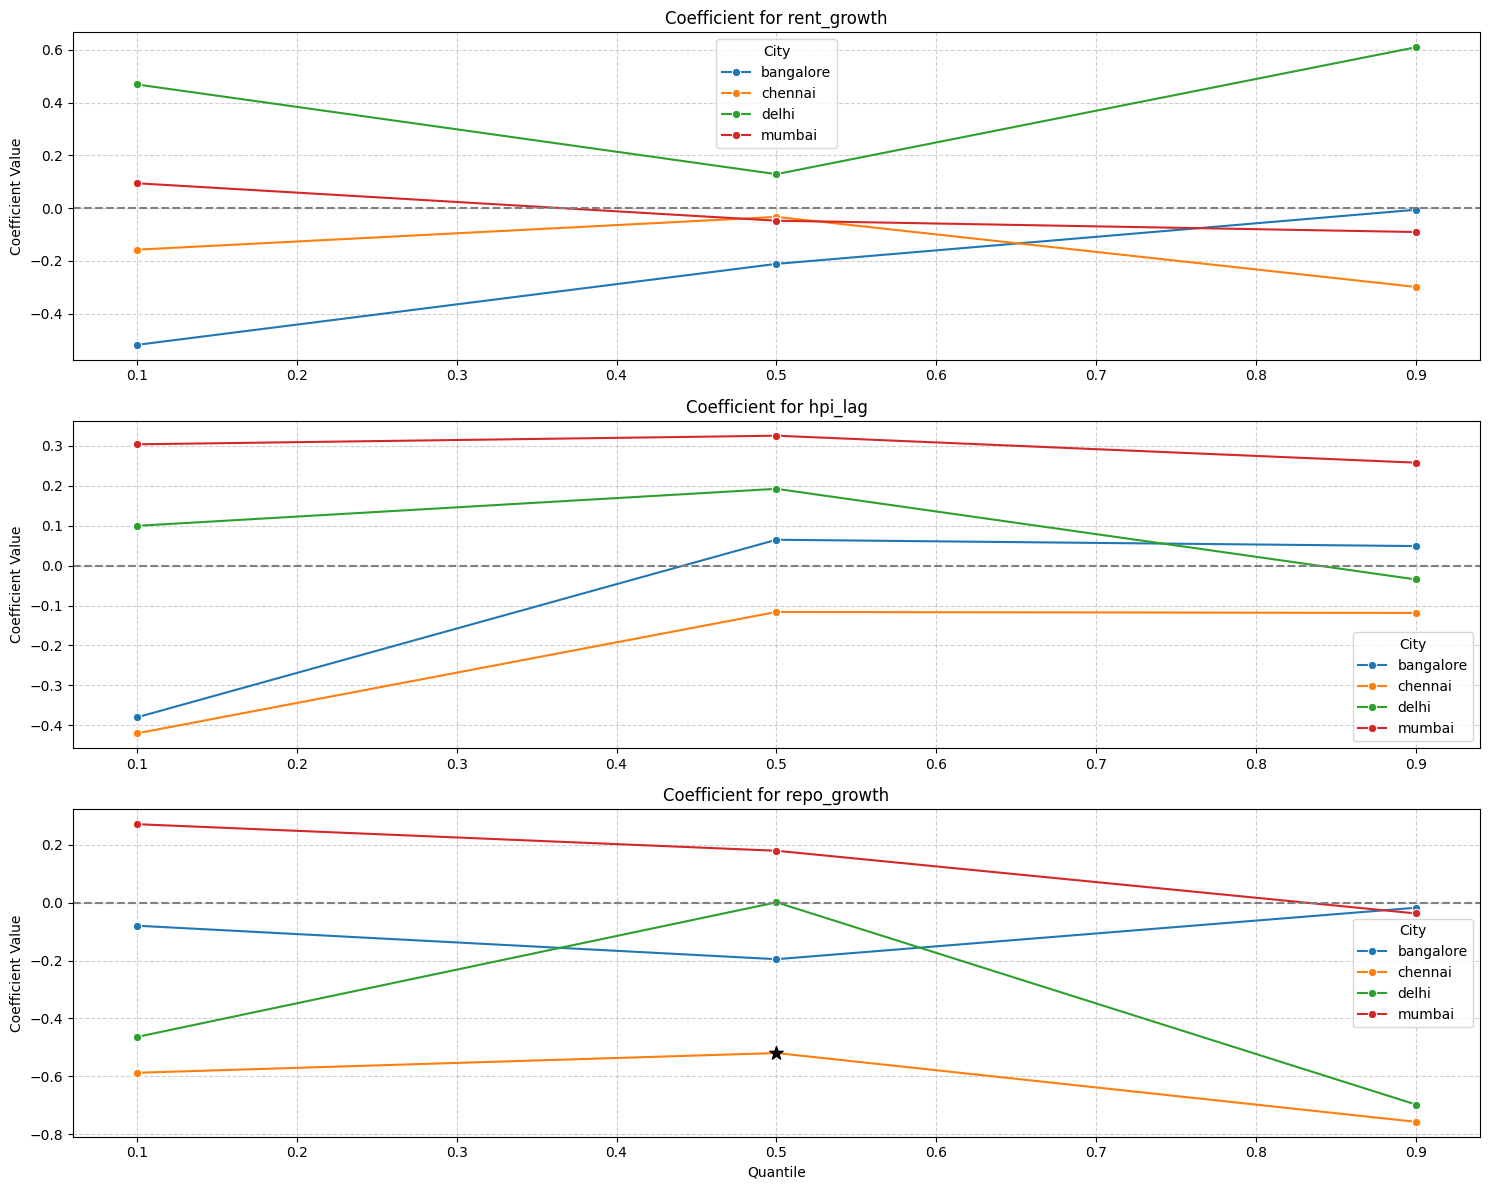

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Define the formula and quantiles (using the formula_city defined previously)
formula_city = "hpi_growth ~ rent_growth + hpi_lag + repo_growth"
quantiles = [0.1, 0.5, 0.9]
unique_cities = df_dyn['city'].unique()

# Store results
all_results = []

for city_name in unique_cities:
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7:
        print(f"Skipping {city_name} due to insufficient observations.")
        continue

    for q in quantiles:
        model = smf.quantreg(formula_city, df_city)
        res = model.fit(q=q)

        # Extract coefficients and p-values
        params = res.params
        pvalues = res.pvalues

        for param_name in params.index:
            all_results.append({
                'City': city_name,
                'Quantile': q,
                'Variable': param_name,
                'Coefficient': params[param_name],
                'P-value': pvalues[param_name],
                'Significant (p<0.05)': pvalues[param_name] < 0.05
            })

# Create a DataFrame from the collected results
results_df = pd.DataFrame(all_results)

# --- Display as a Table ---
print("### Quantile Regression Coefficients and Significance by City and Quantile\n")
display(results_df)

# --- Plot the Coefficients ---
print("\n### Visualization of Coefficients Across Quantiles by City\n")

# Filter out the 'Intercept' for plotting clarity, as its scale can be very different
plot_df = results_df[results_df['Variable'].isin(['rent_growth', 'hpi_lag', 'repo_growth'])]

# Get unique variables to plot separately
unique_variables = plot_df['Variable'].unique()

plt.figure(figsize=(15, 12))
for i, var in enumerate(unique_variables):
    plt.subplot(len(unique_variables), 1, i + 1)
    sns.lineplot(data=plot_df[plot_df['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df[(plot_df['Variable'] == var) & (plot_df['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.grid(True, linestyle='--', alpha=0.6)
    if i < len(unique_variables) - 1:
        plt.xlabel('') # Remove x-label for intermediate plots
    else:
        plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

### Quantile Regression Coefficients and Significance by City and Quantile (Updated Formula)



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


,City,Quantile,Variable,Coefficient,P-value,Significant (p<0.05)
0,bangalore,0.1,Intercept,0.006455,NaN,False
1,bangalore,0.1,hpi_lag,-0.292546,NaN,False
2,bangalore,0.1,rent_growth_lag,-0.051759,NaN,False
3,bangalore,0.1,repo_growth_lag,-0.801858,NaN,False
4,bangalore,0.1,rent_growth,-0.309737,NaN,False
...,...,...,...,...,...,...
67,mumbai,0.9,hpi_lag,0.070683,NaN,False
68,mumbai,0.9,rent_growth_lag,-0.203775,NaN,False
69,mumbai,0.9,repo_growth_lag,-0.289464,NaN,False
70,mumbai,0.9,rent_growth,0.030156,NaN,False



### Visualization of Coefficients Across Quantiles by City (Updated Formula)



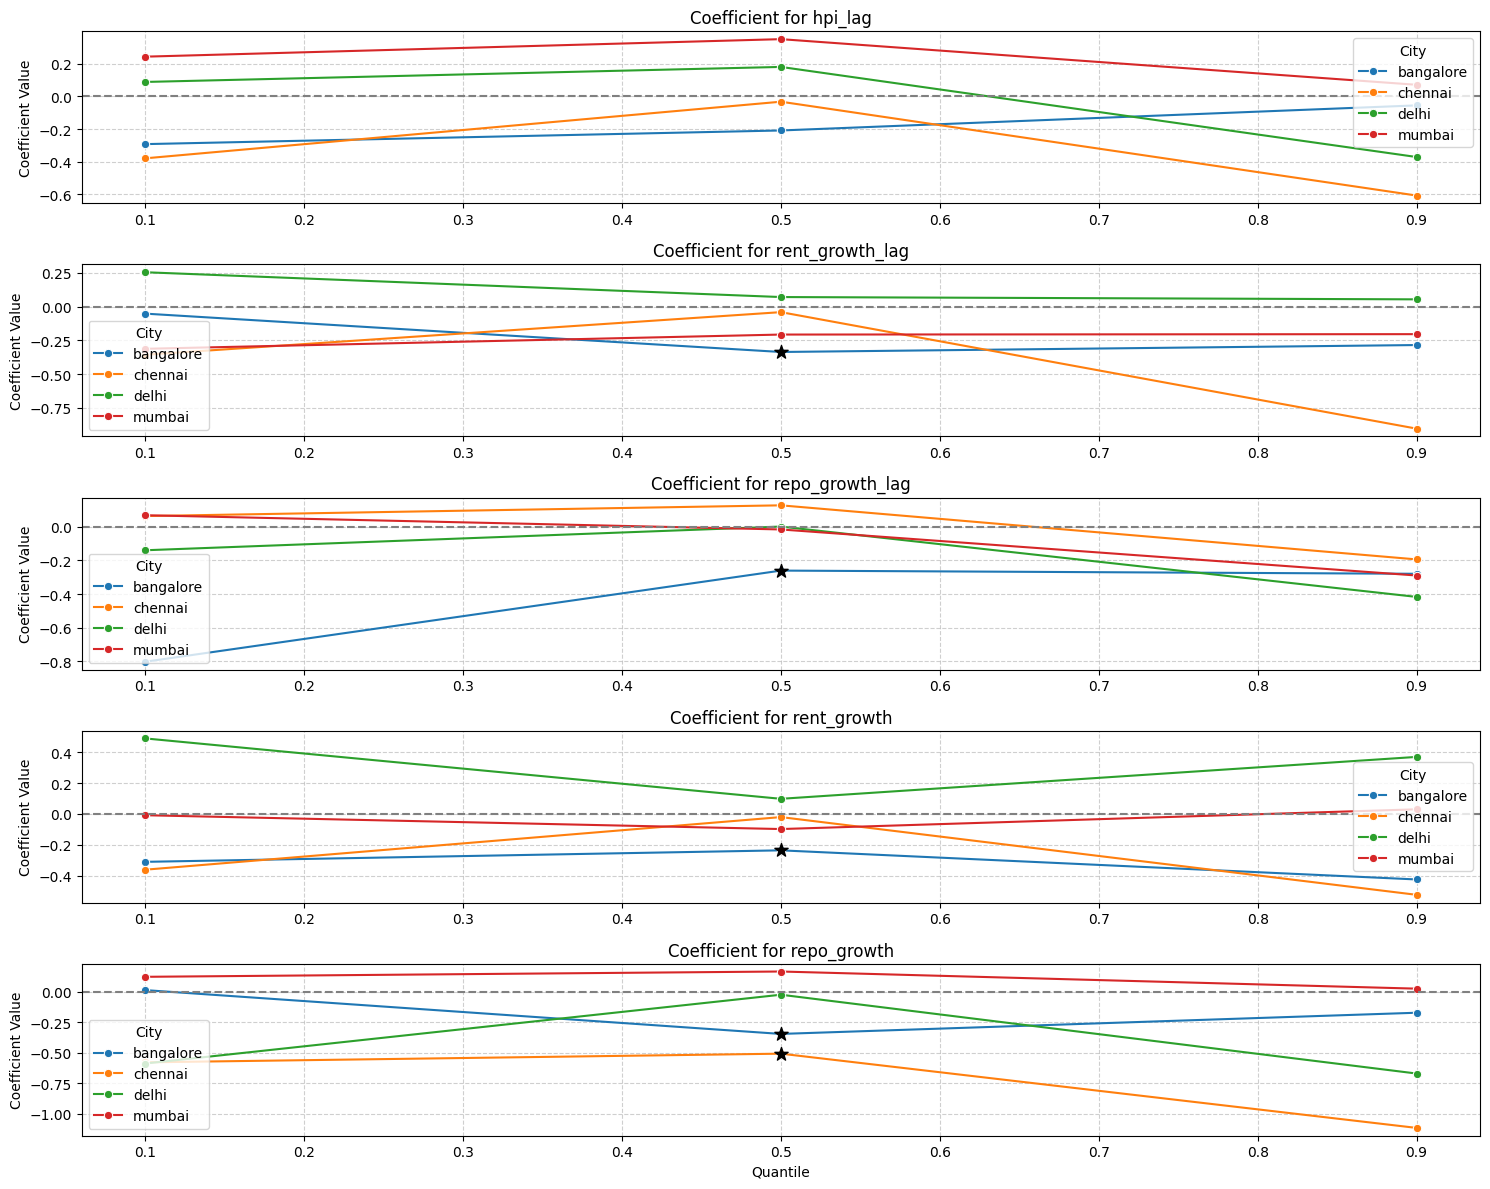

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Define the formula and quantiles (using the formula_city defined previously)
formula_city = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth" # Updated formula
quantiles = [0.1, 0.5, 0.9]
unique_cities = df_dyn['city'].unique()

# Store results
all_results_new = []

for city_name in unique_cities:
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7:
        print(f"Skipping {city_name} due to insufficient observations.")
        continue

    for q in quantiles:
        model = smf.quantreg(formula_city, df_city)
        res = model.fit(q=q)

        # Extract coefficients and p-values
        params = res.params
        pvalues = res.pvalues

        for param_name in params.index:
            all_results_new.append({
                'City': city_name,
                'Quantile': q,
                'Variable': param_name,
                'Coefficient': params[param_name],
                'P-value': pvalues[param_name],
                'Significant (p<0.05)': pvalues[param_name] < 0.05
            })

# Create a DataFrame from the collected results
results_df_new = pd.DataFrame(all_results_new)

# --- Display as a Table ---
print("### Quantile Regression Coefficients and Significance by City and Quantile (Updated Formula)\n")
display(results_df_new)

# --- Plot the Coefficients ---
print("\n### Visualization of Coefficients Across Quantiles by City (Updated Formula)\n")

# Filter out the 'Intercept' for plotting clarity, as its scale can be very different
plot_df_new = results_df_new[results_df_new['Variable'].isin(['rent_growth', 'repo_growth', 'rent_growth_lag', 'hpi_lag', 'repo_growth_lag'])]

# Get unique variables to plot separately
unique_variables_new = plot_df_new['Variable'].unique()

plt.figure(figsize=(15, 12))
for i, var in enumerate(unique_variables_new):
    plt.subplot(len(unique_variables_new), 1, i + 1)
    sns.lineplot(data=plot_df_new[plot_df_new['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df_new[(plot_df_new['Variable'] == var) & (plot_df_new['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.grid(True, linestyle='--', alpha=0.6)
    if i < len(unique_variables_new) - 1:
        plt.xlabel('') # Remove x-label for intermediate plots
    else:
        plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')

plt.tight_layout()
plt.show()


In [109]:
results_df_new.to_csv('quantile_regression_results.csv', index=False)


In [110]:
print(df.columns)

Index(['city', 'quarter', 'rent', 'hpi', 'rent_growth', 'hpi_growth',
       'valuation_gap', 'repo_rate', 'hpi_lag', 'rent_lag', 'repo_growth',
       'rent_growth_lag', 'repo_growth_lag', 'quarter_formatted',
       'quarter_dt'],
      dtype='object')


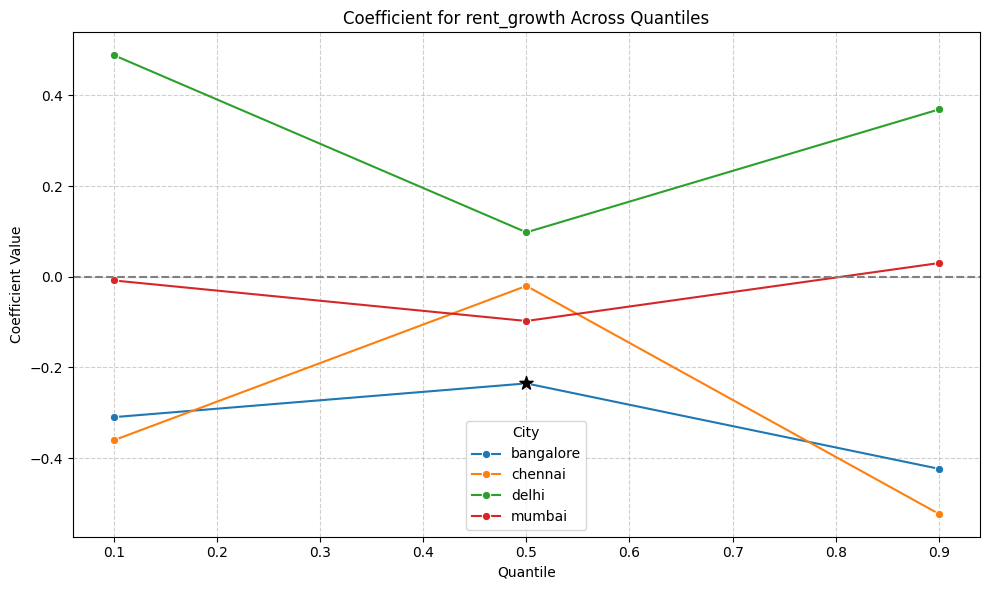

In [111]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df_new[plot_df_new['Variable'] == 'rent_growth'], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

# Add significance markers
for _, row in plot_df_new[(plot_df_new['Variable'] == 'rent_growth') & (plot_df_new['Significant (p<0.05)'] == True)].iterrows():
    plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

plt.title('Coefficient for rent_growth Across Quantiles')
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Quantile')
plt.ylabel('Coefficient Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Coefficients for Each Variable Across Quantiles (Segmented by City)

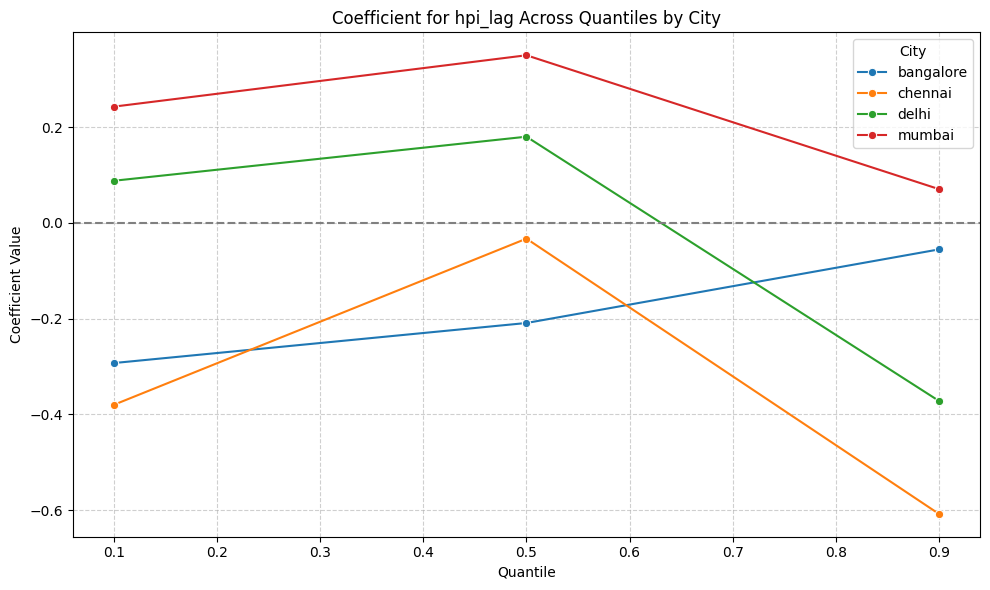

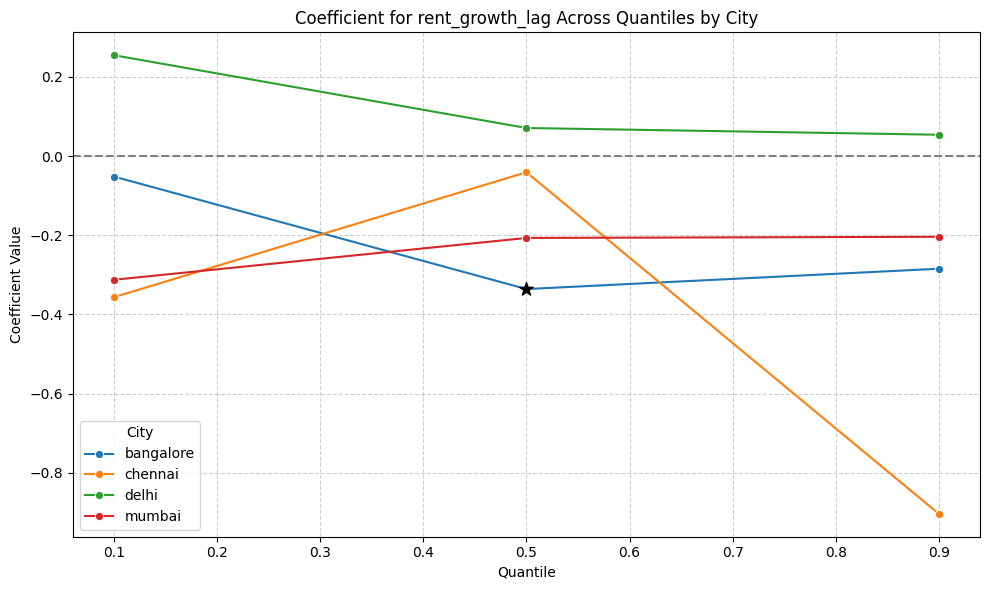

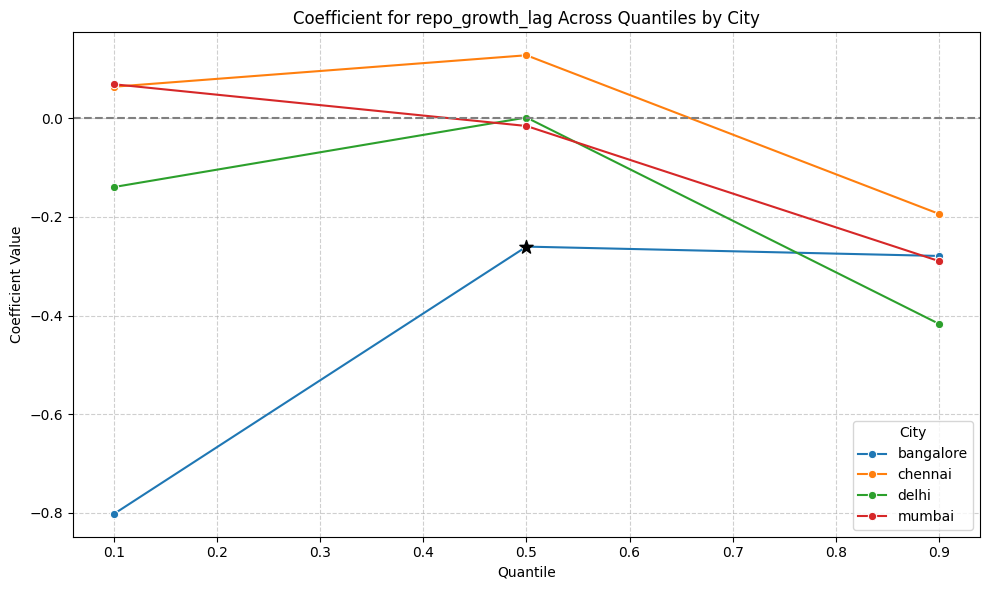

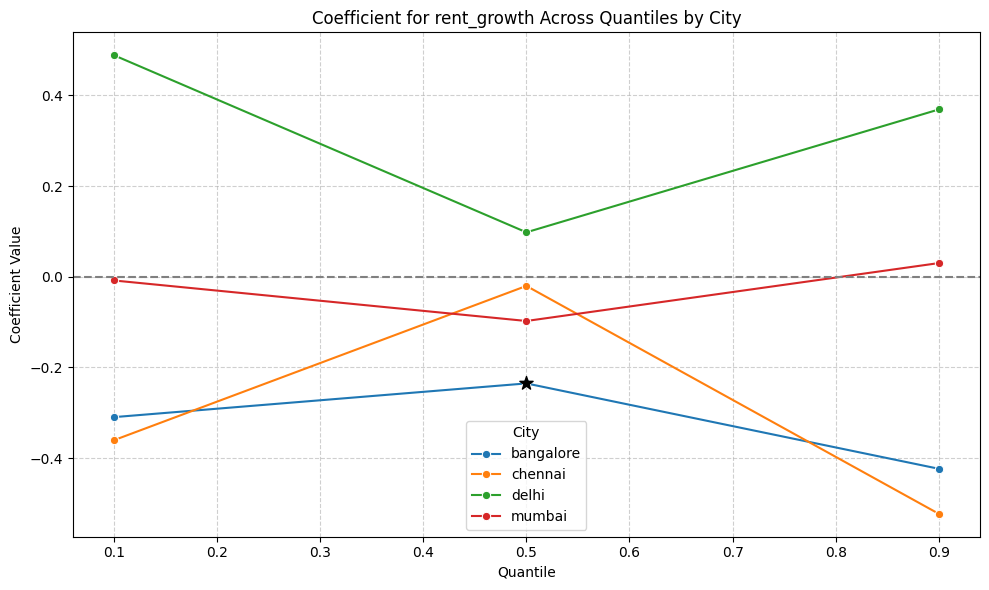

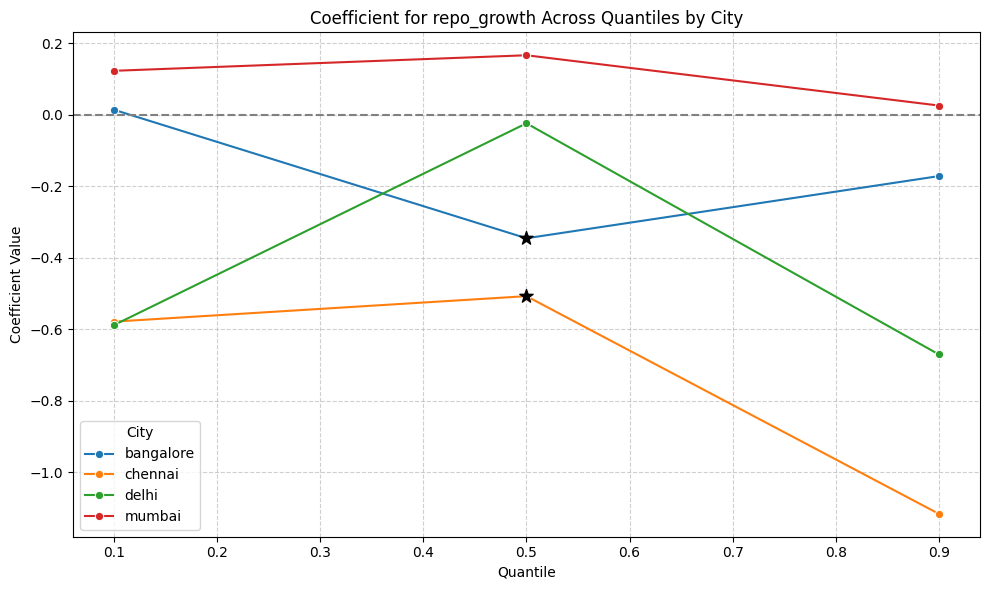

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save plots if it doesn't exist
plot_dir_vars = 'variable_plots_by_city'
os.makedirs(plot_dir_vars, exist_ok=True)

# Filter out the 'Intercept' for plotting clarity
plot_df_vars = results_df_new[results_df_new['Variable'].isin(['hpi_lag', 'rent_growth_lag', 'repo_growth_lag', 'rent_growth', 'repo_growth'])]
unique_variables_to_plot = plot_df_vars['Variable'].unique()

for var in unique_variables_to_plot:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=plot_df_vars[plot_df_vars['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df_vars[(plot_df_vars['Variable'] == var) & (plot_df_vars['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var} Across Quantiles by City')
    plt.axhline(0, color='grey', linestyle='--')
    plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # Save the figure with a unique name
    plt.savefig(os.path.join(plot_dir_vars, f'{var}_coefficients_by_city.png'))
    plt.show()

### Coefficients for Each City Across Quantiles (Segmented by Variable)

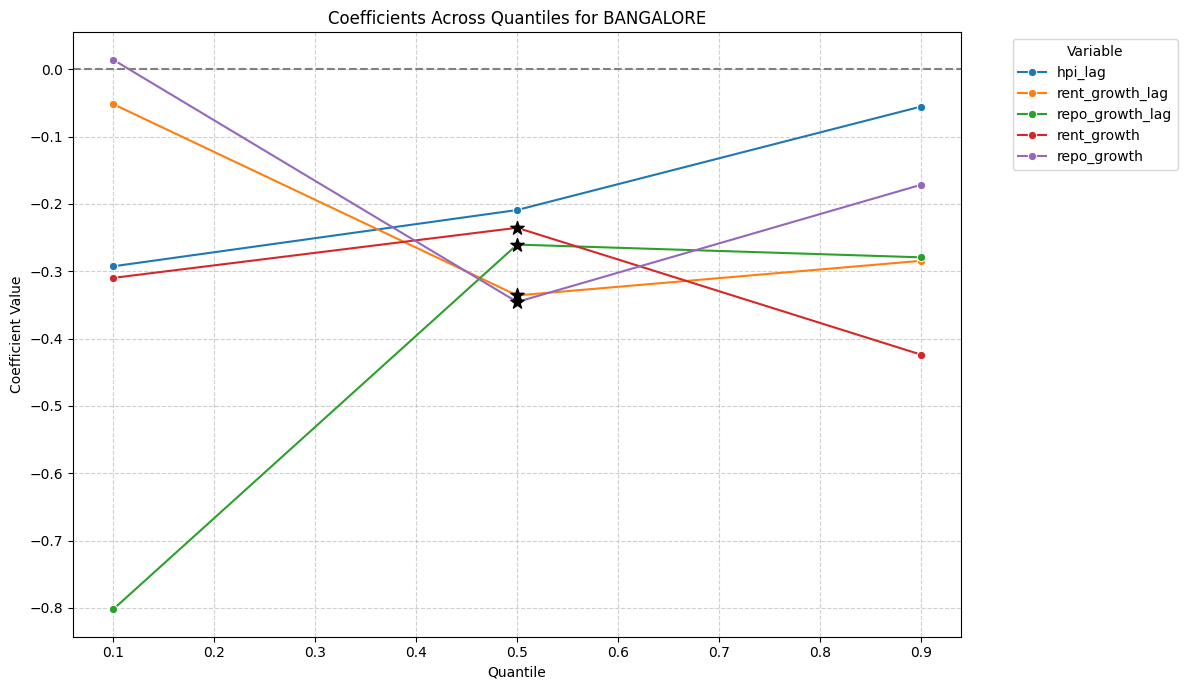

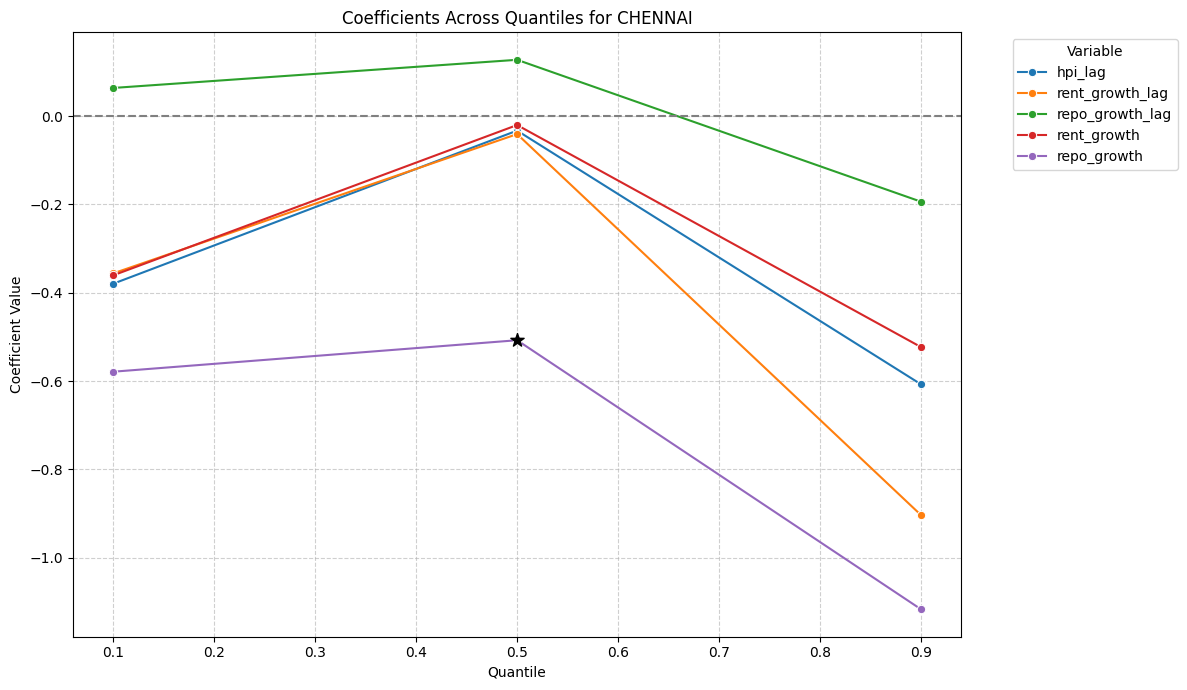

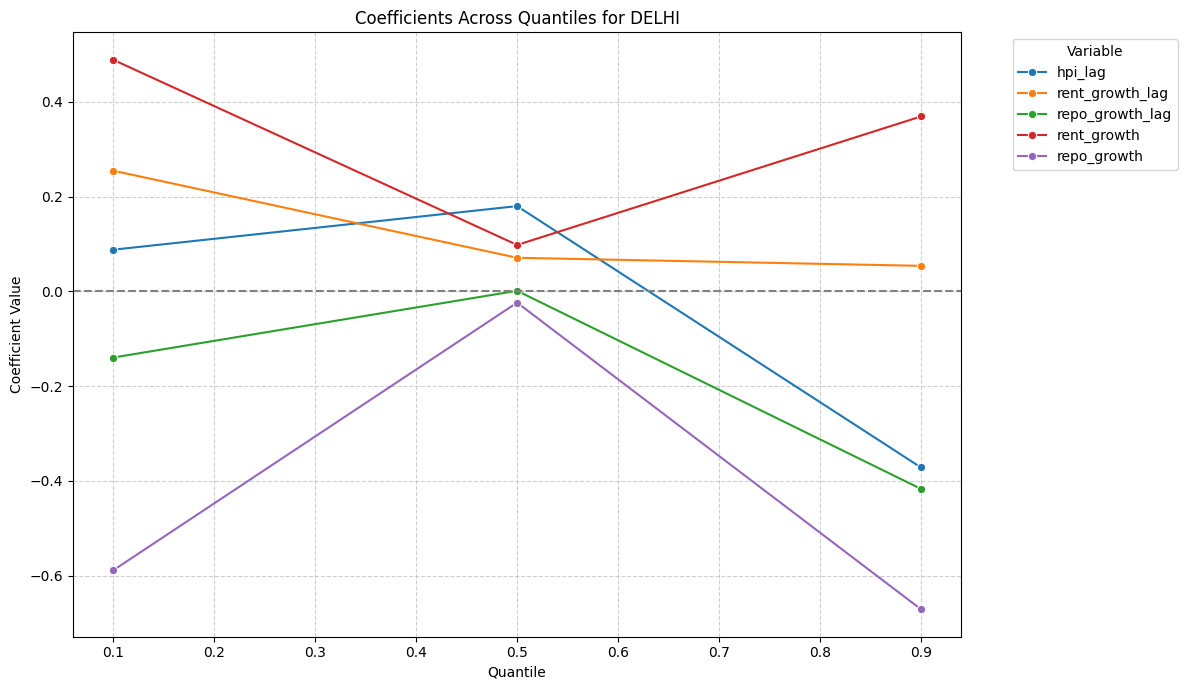

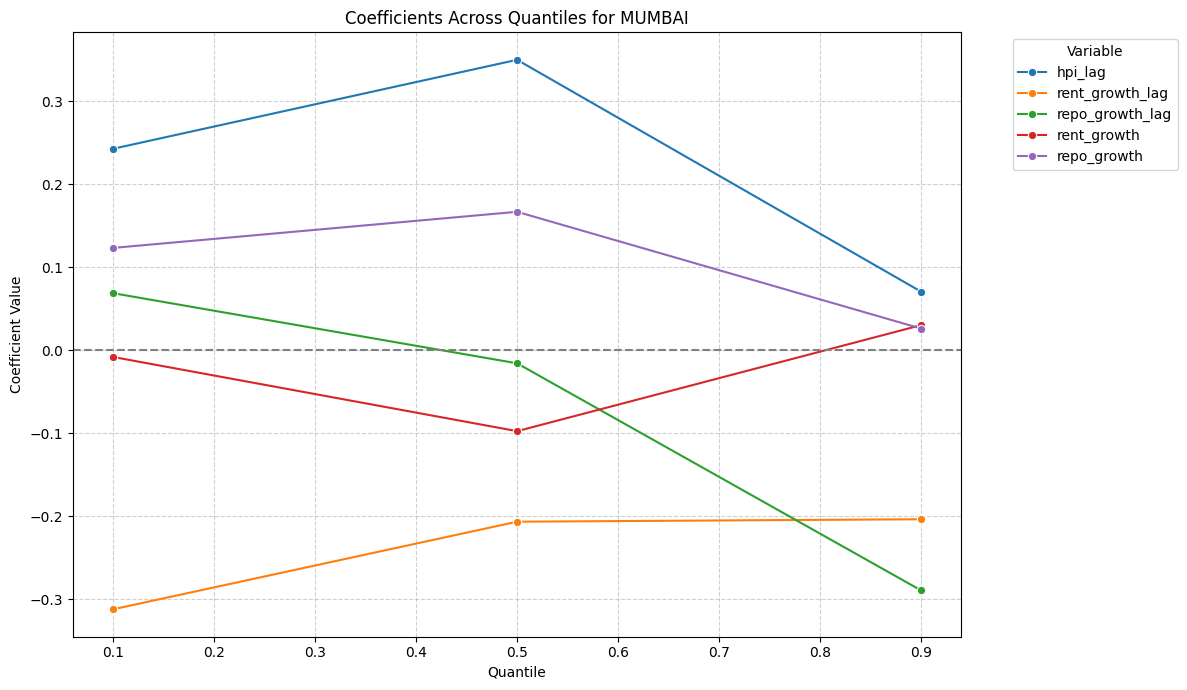

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save plots if it doesn't exist
plot_dir_cities = 'city_plots_by_variable'
os.makedirs(plot_dir_cities, exist_ok=True)

unique_cities_to_plot = results_df_new['City'].unique()

for city_name in unique_cities_to_plot:
    plt.figure(figsize=(12, 7))
    # Filter out Intercept for city-specific plots as well for better scaling of other coefficients
    df_city_plot = results_df_new[(results_df_new['City'] == city_name) & (~results_df_new['Variable'].str.contains('Intercept'))]

    sns.lineplot(data=df_city_plot, x='Quantile', y='Coefficient', hue='Variable', marker='o', errorbar=None)

    # Add significance markers
    for _, row in df_city_plot[df_city_plot['Significant (p<0.05)'] == True].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficients Across Quantiles for {city_name.upper()}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # Save the figure with a unique name
    plt.savefig(os.path.join(plot_dir_cities, f'{city_name.lower()}_coefficients_by_variable.png'))
    plt.show()

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# Ensure 'quarter_dt' column is in datetime format, it should already be from previous steps
# If it's not present or not in datetime, uncomment and modify the line below:
# df['quarter_dt'] = pd.to_datetime(df['quarter_dt'])

# Create a directory to save plots if it doesn't exist
plot_dir = 'time_series_plots_by_city'
os.makedirs(plot_dir, exist_ok=True)

# Define the variables to plot, including lag variables
variables_to_plot = ['rent', 'hpi', 'repo_rate', 'hpi_lag', 'rent_growth_lag', 'repo_growth_lag']

unique_cities = df['city'].unique()

for city_name in unique_cities:
    df_city = df[df['city'] == city_name]

    for var in variables_to_plot:
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_city, x='quarter_dt', y=var) # Changed 'date' to 'quarter_dt'
        plt.title(f'{var.replace("_", " ").title()} Time Series for {city_name.upper()}')
        plt.xlabel('Date')
        plt.ylabel(var.replace("_", " ").title())
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        # Save the figure
        plt.savefig(os.path.join(plot_dir, f'{city_name.lower()}_{var}_time_series.png'))
        plt.close() # Close the plot to free up memory

print(f"Time series plots saved in the '{plot_dir}' folder.")

Time series plots saved in the 'time_series_plots_by_city' folder.


In [115]:
rollingdf=df.groupby("city", observed=False)["rent_growth_lag"].rolling(8).std()

In [116]:
rollingdf.head()

city        
bangalore  1   NaN
           2   NaN
           3   NaN
           4   NaN
           5   NaN
Name: rent_growth_lag, dtype: float64

In [117]:
import pandas as pd

# Re-create df with necessary transformations
df = pd.read_csv('/content/final_model_dataset.csv') # Corrected filename here
df = df.sort_values(["city","quarter"])
df["rent_growth"] = df.groupby("city")["rent"].pct_change(fill_method=None)
df["repo_growth"] = df.groupby("city")["repo_rate"].pct_change(fill_method=None)
# Assuming 'hpi_growth' exists or is calculated earlier. For this context, we can assume it's created during read_csv or earlier processing.
# Based on the notebook state, 'hpi_growth' column is present in the original df from `R7AEPz-c-Jn-`.
df = df.dropna(subset=["rent_growth","hpi_growth","repo_growth"])
df["city"]=df["city"].astype("category")
df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)
df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)

# Re-create 'quarter_dt' column after re-initializing df
df['quarter_formatted'] = df['quarter'].str.replace(r'Q(\d)\s(\d{4})', r'\2Q\1', regex=True)
df['quarter_dt'] = pd.PeriodIndex(df['quarter_formatted'], freq='Q').to_timestamp()

# Re-calculate rent_var_rolling_all_cities
df["rent_var_rolling_all_cities"] = df.groupby("city", observed=False)["rent_growth_lag"].transform(lambda x: x.rolling(window=4).var())

bangalore_rent_growth_lag = df[df['city'] == 'bangalore']['rent_growth_lag']
display(bangalore_rent_growth_lag.head(20))

/tmp/ipykernel_3223/2469150403.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)
/tmp/ipykernel_3223/2469150403.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
/tmp/ipykernel_3223/2469150403.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["repo_growth_lag"] = df.groupby("city")["rep

,rent_growth_lag
1,NaN
2,0.097176
3,0.064463
4,0.190491
5,-0.003357
6,0.070559
7,0.041062
8,0.016893
9,0.082222
10,0.071046


In [118]:
df["rent_var_rolling"] = (
    df[df["city"]=="bangalore"]
    .sort_values("quarter")
    ["rent_growth_lag"]
    .rolling(window=4)
    .var()
)

In [119]:
df["rent_var_rolling_all_cities"] = df.groupby("city", observed=False)["rent_growth_lag"].transform(lambda x: x.rolling(window=4).var())
display(df.head())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,rent_growth_lag,repo_growth_lag,quarter_formatted,quarter_dt,rent_var_rolling_all_cities,rent_var_rolling
1,bangalore,Q1 2016,114.6000,71.406332,0.097176,0.144372,-0.051633,7.657853,NaN,0.043538,-0.016065,NaN,NaN,2016Q1,2016-01-01,NaN,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.064463,0.056838,0.005633,6.962920,0.144372,0.092739,-0.090748,0.097176,-0.016065,2017Q1,2017-01-01,NaN,NaN
3,bangalore,Q1 2018,145.2250,77.997789,0.190491,0.031456,0.142910,7.466353,0.056838,0.062471,0.072302,0.064463,-0.090748,2018Q1,2018-01-01,NaN,NaN
4,bangalore,Q1 2019,144.7375,83.885498,-0.003357,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009235,0.190491,0.072302,2019Q1,2019-01-01,NaN,NaN
5,bangalore,Q1 2020,154.9500,91.129073,0.070559,0.082824,-0.014643,6.727675,0.072772,-0.003363,-0.090536,-0.003357,-0.009235,2020Q1,2020-01-01,0.006495,0.006495


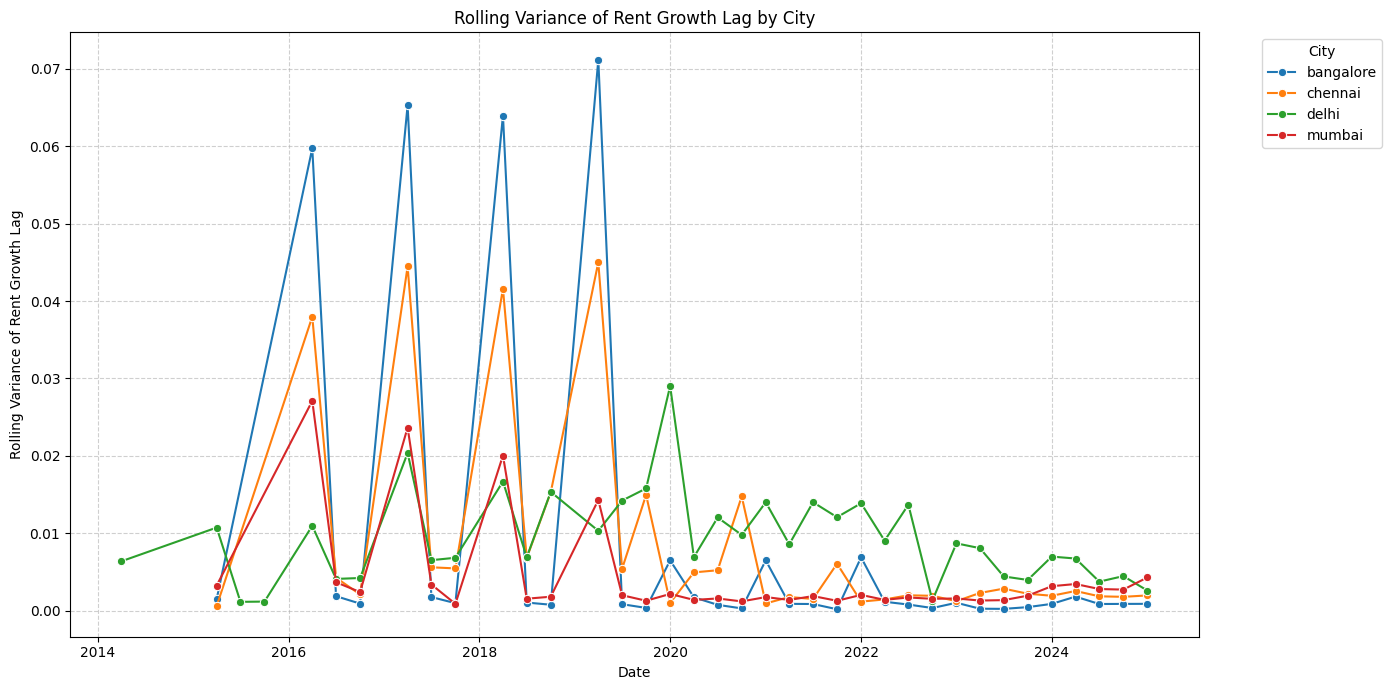

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is in datetime format for plotting
df['quarter_dt'] = pd.to_datetime(df['quarter_dt'])

plt.figure(figsize=(14, 7))
sns.lineplot(data=df.dropna(subset=['rent_var_rolling_all_cities']), x='quarter_dt', y='rent_var_rolling_all_cities', hue='city', marker='o')
plt.title('Rolling Variance of Rent Growth Lag by City')
plt.xlabel('Date')
plt.ylabel('Rolling Variance of Rent Growth Lag')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [121]:
# Calculate rolling variance for other relevant variables
df["hpi_growth_var_rolling"] = df.groupby("city", observed=False)["hpi_growth"].transform(lambda x: x.rolling(window=4).var())
df["repo_growth_var_rolling"] = df.groupby("city", observed=False)["repo_growth"].transform(lambda x: x.rolling(window=4).var())
df["hpi_lag_var_rolling"] = df.groupby("city", observed=False)["hpi_lag"].transform(lambda x: x.rolling(window=4).var())
df["rent_growth_lag_var_rolling"] = df.groupby("city", observed=False)["rent_growth_lag"].transform(lambda x: x.rolling(window=4).var())
df["repo_growth_lag_var_rolling"] = df.groupby("city", observed=False)["repo_growth_lag"].transform(lambda x: x.rolling(window=4).var())

display(df.head())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,...,repo_growth_lag,quarter_formatted,quarter_dt,rent_var_rolling_all_cities,rent_var_rolling,hpi_growth_var_rolling,repo_growth_var_rolling,hpi_lag_var_rolling,rent_growth_lag_var_rolling,repo_growth_lag_var_rolling
1,bangalore,Q1 2016,114.6000,71.406332,0.097176,0.144372,-0.051633,7.657853,NaN,0.043538,...,NaN,2016Q1,2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.064463,0.056838,0.005633,6.962920,0.144372,0.092739,...,-0.016065,2017Q1,2017-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bangalore,Q1 2018,145.2250,77.997789,0.190491,0.031456,0.142910,7.466353,0.056838,0.062471,...,-0.090748,2018Q1,2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bangalore,Q1 2019,144.7375,83.885498,-0.003357,0.072772,-0.076135,7.397403,0.031456,0.174366,...,0.072302,2019Q1,2019-01-01,NaN,NaN,0.002345,0.004443,NaN,NaN,NaN
5,bangalore,Q1 2020,154.9500,91.129073,0.070559,0.082824,-0.014643,6.727675,0.072772,-0.003363,...,-0.009235,2020Q1,2020-01-01,0.006495,0.006495,0.000502,0.006084,0.002345,0.006495,0.004443


### Visualizing Rolling Variance for Other Variables

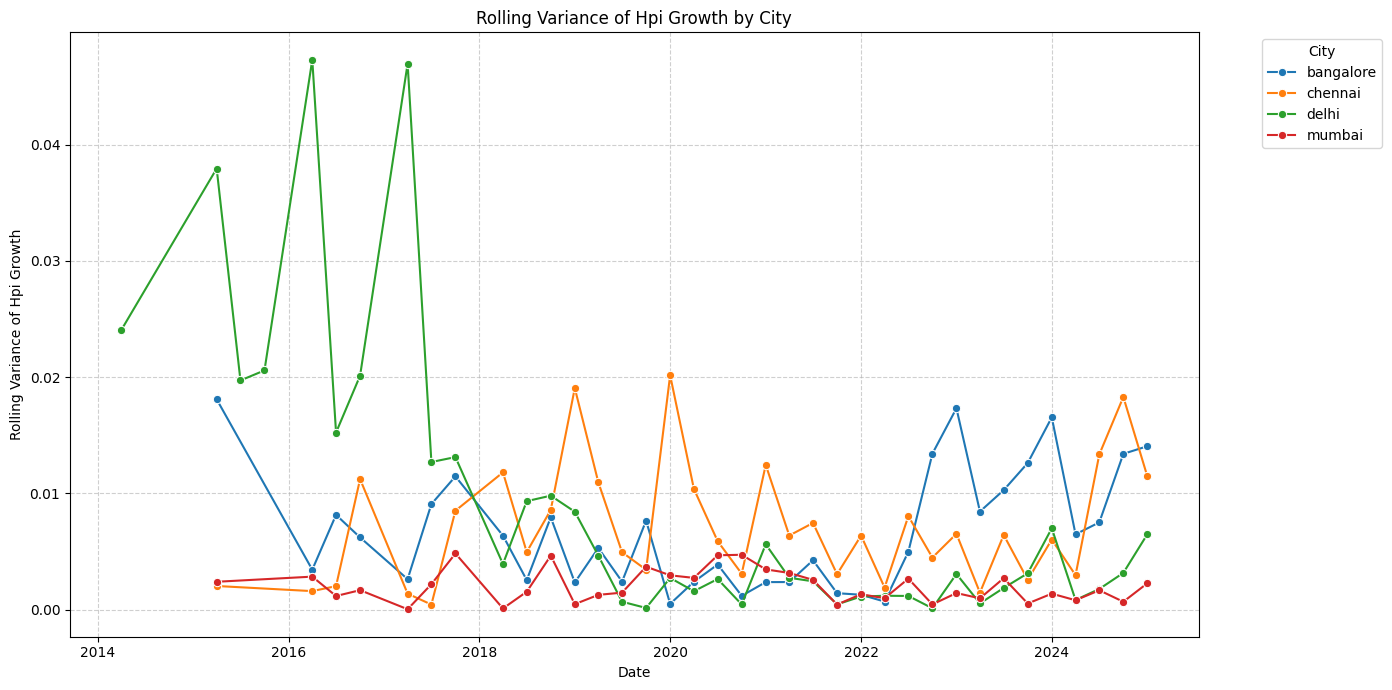

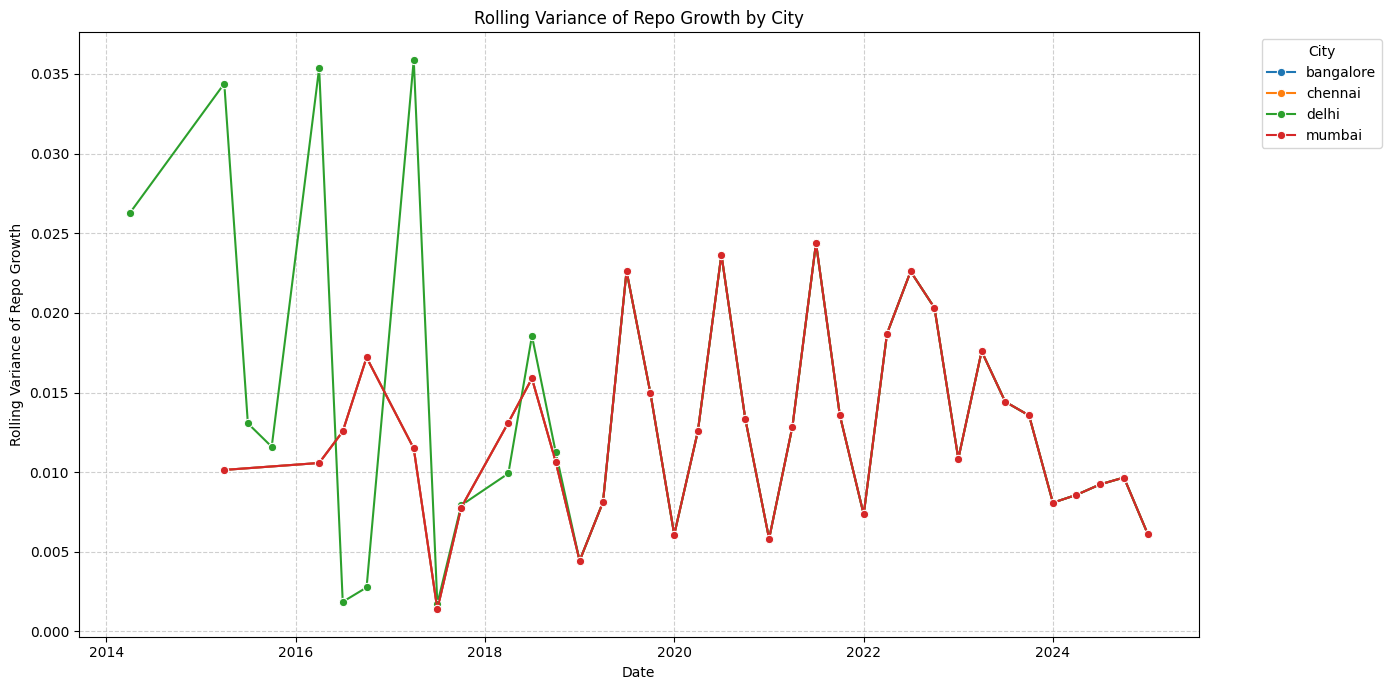

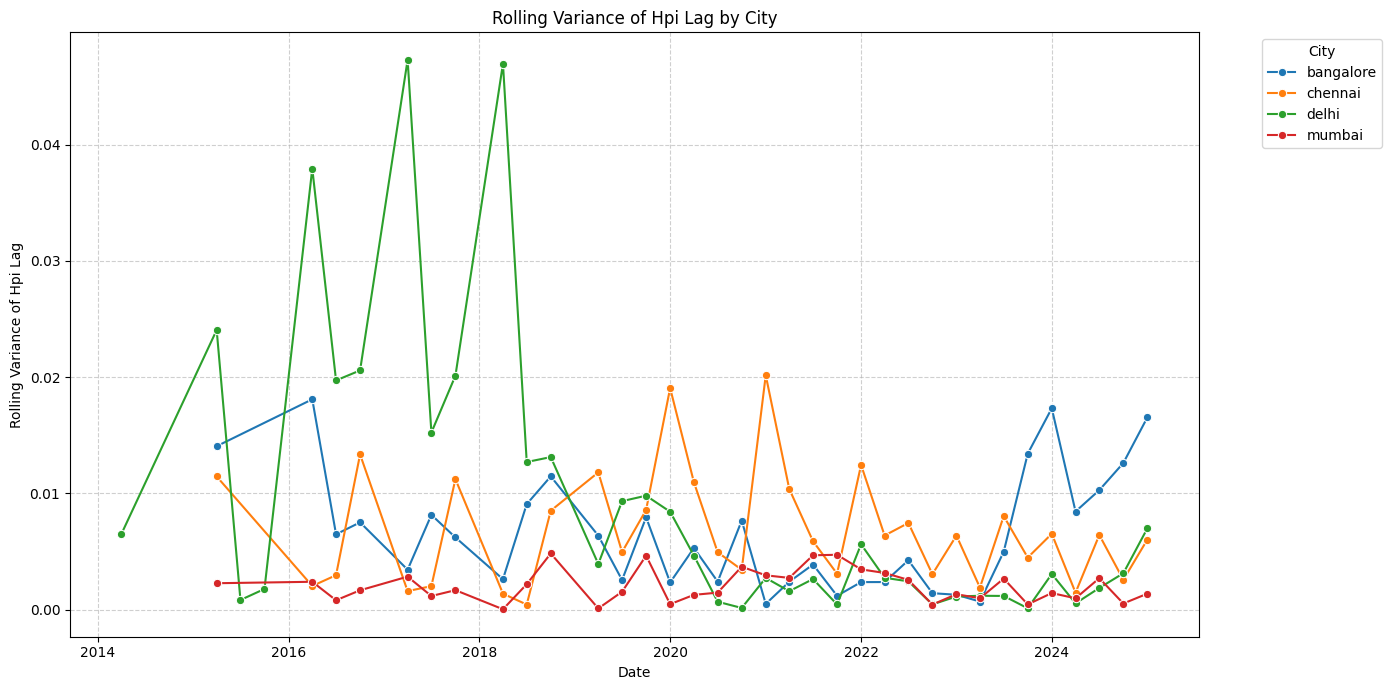

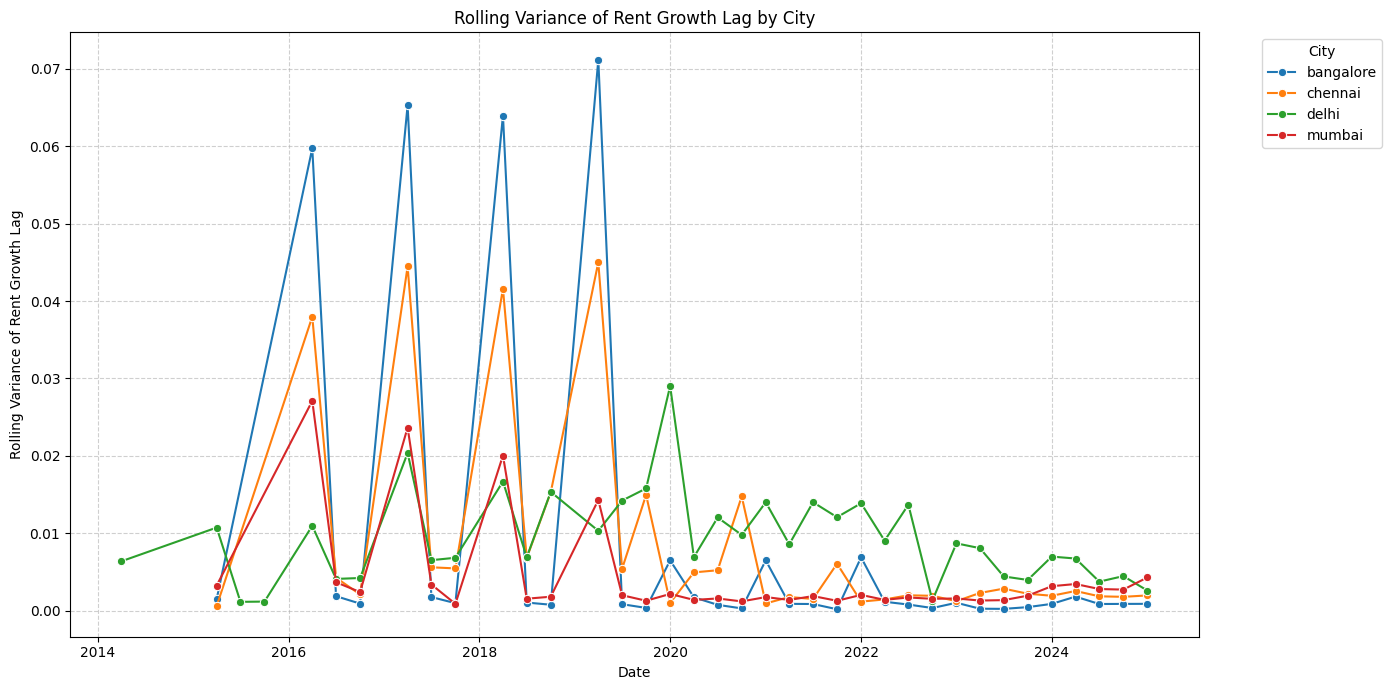

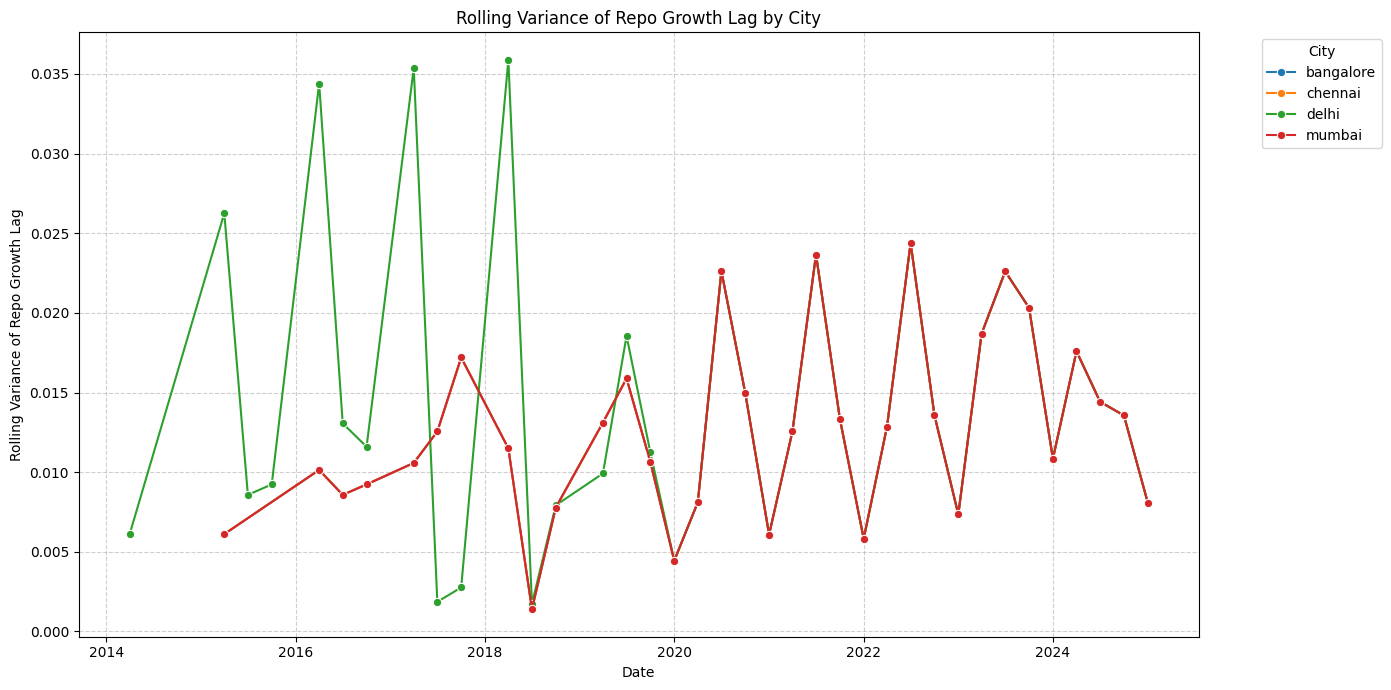

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'date' column is in datetime format for plotting
df['quarter_dt'] = pd.to_datetime(df['quarter_dt'])

rolling_variance_cols = [
    'hpi_growth_var_rolling',
    'repo_growth_var_rolling',
    'hpi_lag_var_rolling',
    'rent_growth_lag_var_rolling',
    'repo_growth_lag_var_rolling'
]

# Create a directory to save plots if it doesn't exist
plot_dir_rolling_var = 'rolling_variance_plots'
os.makedirs(plot_dir_rolling_var, exist_ok=True)

for col in rolling_variance_cols:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df.dropna(subset=[col]), x='quarter_dt', y=col, hue='city', marker='o')
    plt.title(f'Rolling Variance of {col.replace("_var_rolling", "").replace("_", " ").title()} by City')
    plt.xlabel('Date')
    plt.ylabel(f'Rolling Variance of {col.replace("_var_rolling", "").replace("_", " ").title()}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # Save the figure to the specified directory
    plt.savefig(os.path.join(plot_dir_rolling_var, f'{col}.png'))
    plt.show()